# PMID36973557_NatBiotechnol2023_T-cell-depleted

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
from numba.core.errors import NumbaDeprecationWarning
warnings.simplefilter("ignore", category=NumbaDeprecationWarning)
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)

In [3]:
import os
import sys
import numpy as np
import pandas as pd

In [4]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import scanpy as sc
from anndata import AnnData
from mudata import MuData

import cellrank as cr

In [6]:
import scmagnify as scm
from scmagnify.settings import settings
import scmagnify.logging as logg

In [7]:
import session_info
session_info.show()

## Configurations

In [8]:
%matplotlib inline
scm.settings.verbosity = 4
sc.settings.set_figure_params(
    dpi=100,
    facecolor="white",
    frameon=False,
) 

plt.rcParams["savefig.dpi"] = 300
plt.rcParams["image.cmap"] = "Spectral_r"
plt.rcParams["font.family"] = "Arial"
plt.rcParams['grid.alpha'] = 0

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams["text.usetex"] = False

In [20]:
dirPjtHome = "/csb3/project/chenxufeng/Data/PMID36973557_NatBiotechnol2023_T-cell-depleted/"
os.chdir(dirPjtHome)

In [21]:
plt.rcParams["savefig.directory"] = os.path.join(dirPjtHome, "figures")

In [22]:
workDir = os.path.join(dirPjtHome, "scmagnify_wd")
scm.set_workspace(workDir)

workspace: /csb3/project/chenxufeng/Data/PMID36973557_NatBiotechnol2023_T-cell-depleted/scmagnify_wd/
├── data
├── models
├── tmpfiles
└── figures

In [23]:
scm.set_genome(
    version="hg38",
    genomes_dir="/home/chenxufeng/picb_cxf/Ref/human/hg38/"
)

                        Genome Information                        
┏━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Version ┃ Provider ┃ Directory                                 ┃
┡━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ hg38    │ UCSC     │ /home/chenxufeng/picb_cxf/Ref/human/hg38/ │
└─────────┴──────────┴───────────────────────────────────────────┘

In [24]:
!ls scmagnify_wd/data/

eNet_regulon_3.csv		 t-cell-depleted-bm_Mono_03.h5mu
t-cell-depleted-bm_01.h5mu	 t-cell-depleted-bm_Mono_04.h5mu
t-cell-depleted-bm_02.h5mu	 t-cell-depleted-bm_NaiveB_02.h5mu
t-cell-depleted-bm_Ery_02.h5mu	 t-cell-depleted-bm_NaiveB_03.h5mu
t-cell-depleted-bm_Ery_03.h5mu	 t-cell-depleted-bm_NaiveB_04.h5mu
t-cell-depleted-bm_Ery_04.h5mu	 t-cell-depleted-bm_preprocessed_NaiveB.h5mu
t-cell-depleted-bm_Mono_02.h5mu


In [25]:
fig_dir = "/home/chenxufeng/WorkSpace/scMagnify/scMagnify-figures/figures/Fig3/" 
if not os.path.exists(fig_dir):
    os.makedirs(fig_dir)
data_dir = "/home/chenxufeng/WorkSpace/scMagnify/scMagnify-figures/data/Fig3/"
if not os.path.exists(data_dir):
    os.makedirs(data_dir)

## Load the Data

In [26]:
mdata = scm.read(os.path.join(settings.data_dir, "t-cell-depleted-bm_02.h5mu"))

In [27]:
mdata

MuData object with n_obs × n_vars = 8627 × 233703
  obsm:	'cell_state_masks'
  2 modalities
    ATAC:	8627 x 216477
      obs:	'sample', 'celltype', 'TSSEnrichment', 'NucleosomeRatio', 'nFrags', 'BlacklistRatio', 'SEACell'
      var:	'seqnames', 'start', 'end', 'strand', 'GC', 'Bcells_primed', 'Bcells_lineage_specific'
      uns:	'celltype_colors', 'neighbors', 'sample_colors', 'umap'
      obsm:	'DM_EigenVectors', 'GeneScores', 'X_svd', 'X_umap'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    RNA:	8627 x 17226
      obs:	'sample', 'celltype', 'palantir_pseudotime', 'macrostates_fwd', 'term_states_fwd', 'term_states_fwd_probs', 'clusters_gradients', 'init_states_fwd', 'init_states_fwd_probs', 'n_counts', 'SEACell'
      var:	'highly_variable', 'significant_genes', 'means', 'dispersions', 'dispersions_norm'
      uns:	'T_fwd_params', 'celltype_colors', 'clusters_gradients_colors', 'coarse_fwd', 'eigendecomposition_fwd', 'hvg', 'init_states_fwd_colors', 'log1p', 'macrostates_fwd_colors', 'neighbors', 'sample_colors', 'schur_matrix_fwd', 'term_states_fwd_colors', 'test_assoc', 'umap'
      obsm:	'T_fwd_umap', 'X_FDL', 'X_fate_simplex_fwd', 'X_pca', 'X_umap', 'cell_state_masks', 'cellrank_fate_probabilities', 'init_states_fwd_memberships', 'lineages_fwd', 'macrostates_fwd_memberships', 'schur_vectors_fwd'
      varm:	'test_assoc_res'
      layers:	'MAGIC_imputed_data', 'counts', 'log1p_norm'
      obsp:	'connectivities', 'distances', 'knn'

In [28]:
meta_mdata = scm.read(os.path.join(settings.tmpfiles_dir, "meta_mdata_SEACells_overall.h5mu"))

In [29]:
meta_mdata

MuData object with n_obs × n_vars = 115 × 233703
  obs:	'celltype'
  obsm:	'cell_state_masks'
  2 modalities
    RNA:	115 x 17226
      obs:	'n_counts', 'palantir_pseudotime'
      uns:	'log1p'
      obsm:	'X_umap'
      layers:	'raw'
    ATAC:	115 x 216477
      obs:	'n_counts'
      var:	'GC_bin', 'counts_bin', 'n_cells'
      uns:	'log1p'
      obsm:	'X_svd'
      layers:	'raw'

In [30]:
gdataE = scm.read(os.path.join(settings.data_dir, "t-cell-depleted-bm_Ery_04.h5mu"))
gdataB = scm.read(os.path.join(settings.data_dir, "t-cell-depleted-bm_NaiveB_04.h5mu"))
gdataM = scm.read(os.path.join(settings.data_dir, "t-cell-depleted-bm_Mono_04.h5mu"))

## Figure 3. A

### UMAP

2025-10-04 16:19:29 | [INFO] maxp pruned
2025-10-04 16:19:29 | [INFO] LTSH dropped
2025-10-04 16:19:29 | [INFO] cmap pruned
2025-10-04 16:19:29 | [INFO] kern pruned
2025-10-04 16:19:29 | [INFO] post pruned
2025-10-04 16:19:29 | [INFO] PCLT dropped
2025-10-04 16:19:29 | [INFO] DSIG dropped
2025-10-04 16:19:29 | [INFO] glyf pruned
2025-10-04 16:19:29 | [INFO] Added gid0 to subset
2025-10-04 16:19:29 | [INFO] Added first four glyphs to subset
2025-10-04 16:19:29 | [INFO] Closing glyph list over 'glyf': 30 glyphs before
2025-10-04 16:19:29 | [INFO] Glyph names: ['.notdef', '.null', 'B', 'C', 'D', 'E', 'H', 'L', 'M', 'N', 'P', 'S', 'a', 'c', 'd', 'e', 'g', 'i', 'l', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'r', 'space', 't', 'two', 'v', 'y']
2025-10-04 16:19:29 | [INFO] Glyph IDs:   [0, 1, 2, 3, 20, 21, 37, 38, 39, 40, 43, 47, 48, 49, 51, 54, 68, 70, 71, 72, 74, 76, 79, 81, 82, 83, 85, 87, 89, 92]
2025-10-04 16:19:29 | [INFO] Closed glyph list over 'glyf': 30 glyphs after
2025-10-04 16:19:

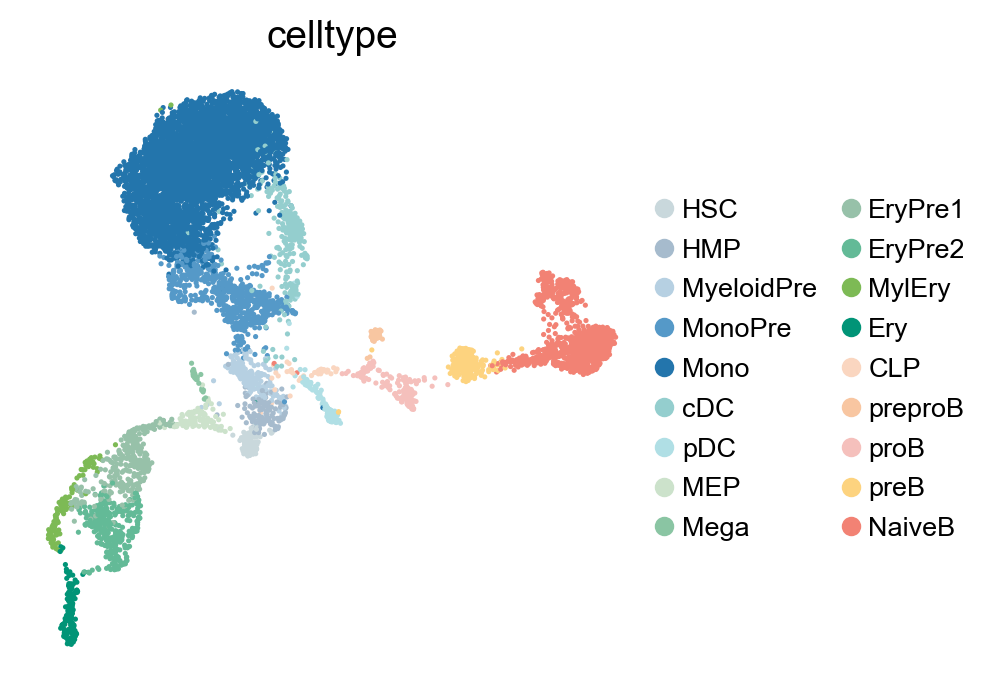

In [31]:
ax = sc.pl.embedding(mdata["RNA"], 
                basis="umap", color=["celltype"], 
                legend_fontsize="x-small",  
                frameon=False, show=False)

ax.figure.savefig(os.path.join(fig_dir, "Fig3a-celltype_umap.pdf"), bbox_inches='tight')

### SEACell UMAP

In [32]:
sc.tl.pca(meta_mdata["RNA"])
sc.pp.neighbors(meta_mdata["RNA"], use_rep="X_pca", n_neighbors=15)

<Axes: ylabel='Density'>

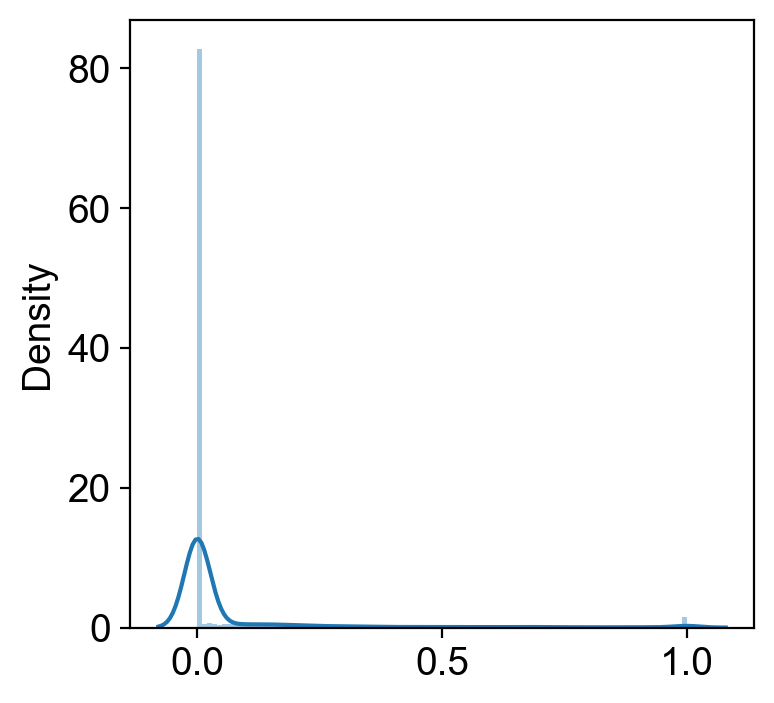

In [33]:
sns.distplot(meta_mdata["RNA"].obsp['connectivities'].A.flatten(), bins=100)

In [34]:
pk = cr.kernels.PseudotimeKernel(meta_mdata["RNA"], time_key="palantir_pseudotime").compute_transition_matrix()
A = pk.transition_matrix

  0%|          | 0/115 [00:00<?, ?cell/s]

In [35]:
A = A.toarray()

for i in range(len(A)):
    for j in range(len(A)):
        if A[i][j] > 0 and A[j][i] > 0 and A[i][j] > A[j][i]:
            A[j][i] = 0

In [36]:
meta_mdata["RNA"]

AnnData object with n_obs × n_vars = 115 × 17226
    obs: 'n_counts', 'palantir_pseudotime'
    uns: 'log1p', 'pca', 'neighbors'
    obsm: 'X_umap', 'X_pca'
    varm: 'PCs'
    layers: 'raw'
    obsp: 'distances', 'connectivities'

In [37]:
# quantile 
A_q = np.quantile(A, 0.99)
A[A < A_q] = 0
A[A >= A_q] = 1

In [38]:
A[A > A_q].shape

(133,)

In [39]:
meta_mdata["RNA"].obsp['connectivities'] = A.copy()

2025-10-04 16:19:45 | [INFO] maxp pruned
2025-10-04 16:19:45 | [INFO] LTSH dropped
2025-10-04 16:19:45 | [INFO] cmap pruned
2025-10-04 16:19:45 | [INFO] kern pruned
2025-10-04 16:19:45 | [INFO] post pruned
2025-10-04 16:19:45 | [INFO] PCLT dropped
2025-10-04 16:19:45 | [INFO] DSIG dropped
2025-10-04 16:19:45 | [INFO] glyf pruned
2025-10-04 16:19:45 | [INFO] Added gid0 to subset
2025-10-04 16:19:45 | [INFO] Added first four glyphs to subset
2025-10-04 16:19:45 | [INFO] Closing glyph list over 'glyf': 24 glyphs before
2025-10-04 16:19:45 | [INFO] Glyph names: ['.notdef', '.null', 'a', 'd', 'e', 'eight', 'four', 'i', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'p', 'period', 'r', 's', 'six', 'space', 't', 'two', 'u', 'underscore', 'zero']
2025-10-04 16:19:45 | [INFO] Glyph IDs:   [0, 1, 2, 3, 17, 19, 21, 23, 25, 27, 66, 68, 71, 72, 76, 79, 80, 81, 82, 83, 85, 86, 87, 88]
2025-10-04 16:19:45 | [INFO] Closed glyph list over 'glyf': 24 glyphs after
2025-10-04 16:19:45 | [INFO] Glyph names: ['.no

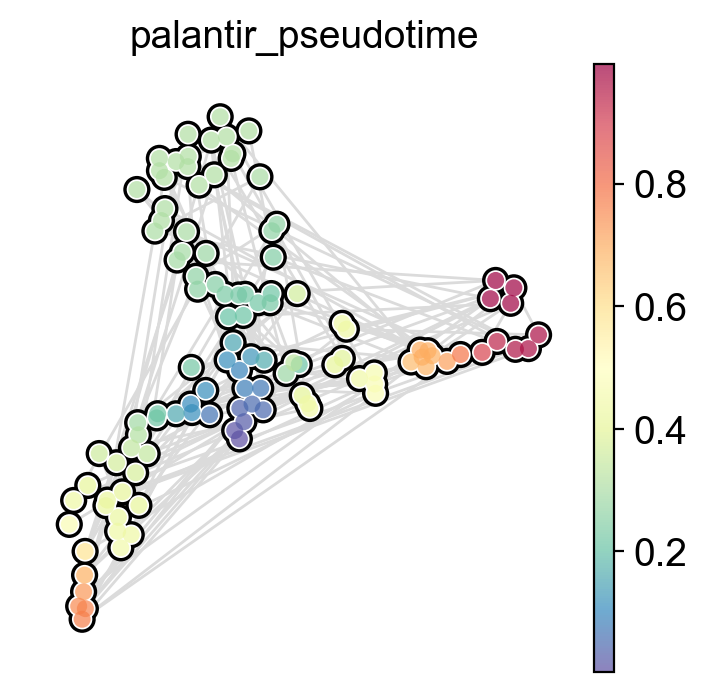

In [40]:
sc.pl.umap(meta_mdata["RNA"], 
           color=["palantir_pseudotime"], color_map="Spectral_r",
           frameon=False, 
           size=150, 
        #    neighbors_key="transition_matrix",
           edges=True, 
           edges_width=1,
           edges_color="#DBDBDB",
           add_outline=True,
           outline_width=(0.2, 0.1),
           save="_meta_palantir_pseudotime.pdf",)

## Cell State Selection

2025-09-20 22:57:41 | [INFO] maxp pruned
2025-09-20 22:57:41 | [INFO] LTSH dropped
2025-09-20 22:57:41 | [INFO] cmap pruned
2025-09-20 22:57:41 | [INFO] kern pruned
2025-09-20 22:57:41 | [INFO] post pruned
2025-09-20 22:57:41 | [INFO] PCLT dropped
2025-09-20 22:57:41 | [INFO] DSIG dropped
2025-09-20 22:57:41 | [INFO] glyf pruned
2025-09-20 22:57:41 | [INFO] Added gid0 to subset
2025-09-20 22:57:41 | [INFO] Added first four glyphs to subset
2025-09-20 22:57:41 | [INFO] Closing glyph list over 'glyf': 30 glyphs before
2025-09-20 22:57:41 | [INFO] Glyph names: ['.notdef', '.null', 'B', 'C', 'D', 'E', 'H', 'L', 'M', 'N', 'P', 'S', 'a', 'c', 'd', 'e', 'g', 'i', 'l', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'r', 'space', 't', 'two', 'v', 'y']
2025-09-20 22:57:41 | [INFO] Glyph IDs:   [0, 1, 2, 3, 20, 21, 37, 38, 39, 40, 43, 47, 48, 49, 51, 54, 68, 70, 71, 72, 74, 76, 79, 81, 82, 83, 85, 87, 89, 92]
2025-09-20 22:57:41 | [INFO] Closed glyph list over 'glyf': 30 glyphs after
2025-09-20 22:57:

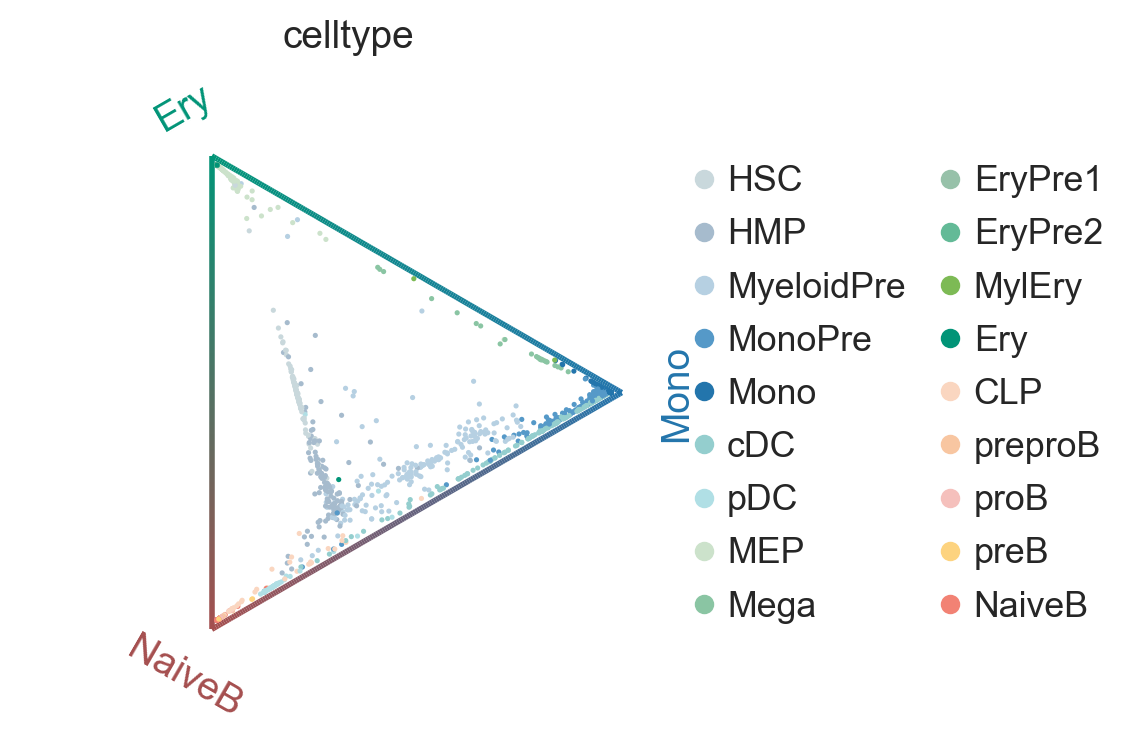

In [79]:
cr.pl.circular_projection(mdata["RNA"], keys=["celltype"], legend_loc="right", save=os.path.join(fig_dir, "SupFig3-cellrank_fate_circular.pdf"))


2025-09-20 22:57:47 | [INFO] maxp pruned
2025-09-20 22:57:47 | [INFO] LTSH dropped
2025-09-20 22:57:47 | [INFO] cmap pruned
2025-09-20 22:57:47 | [INFO] kern pruned
2025-09-20 22:57:47 | [INFO] post pruned
2025-09-20 22:57:47 | [INFO] PCLT dropped
2025-09-20 22:57:47 | [INFO] DSIG dropped
2025-09-20 22:57:47 | [INFO] glyf pruned
2025-09-20 22:57:47 | [INFO] Added gid0 to subset
2025-09-20 22:57:47 | [INFO] Added first four glyphs to subset
2025-09-20 22:57:47 | [INFO] Closing glyph list over 'glyf': 40 glyphs before
2025-09-20 22:57:47 | [INFO] Glyph names: ['.notdef', '.null', 'B', 'C', 'E', 'F', 'M', 'N', 'P', 'R', 'S', 'a', 'b', 'c', 'd', 'e', 'eight', 'five', 'four', 'i', 'l', 'm', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'v', 'y', 'zero']
2025-09-20 22:57:47 | [INFO] Glyph IDs:   [0, 1, 2, 3, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 37, 38, 40, 41, 48, 49, 51, 53, 54, 68, 69, 70, 71, 72, 76, 79, 80, 81, 

INFO     💾 Saving figure to file                                                                                  
         /home/chenxufeng/WorkSpace/scMagnify/scMagnify-figures/figures/Fig3/SupFig3-cell_state_select_t_cell.pdf

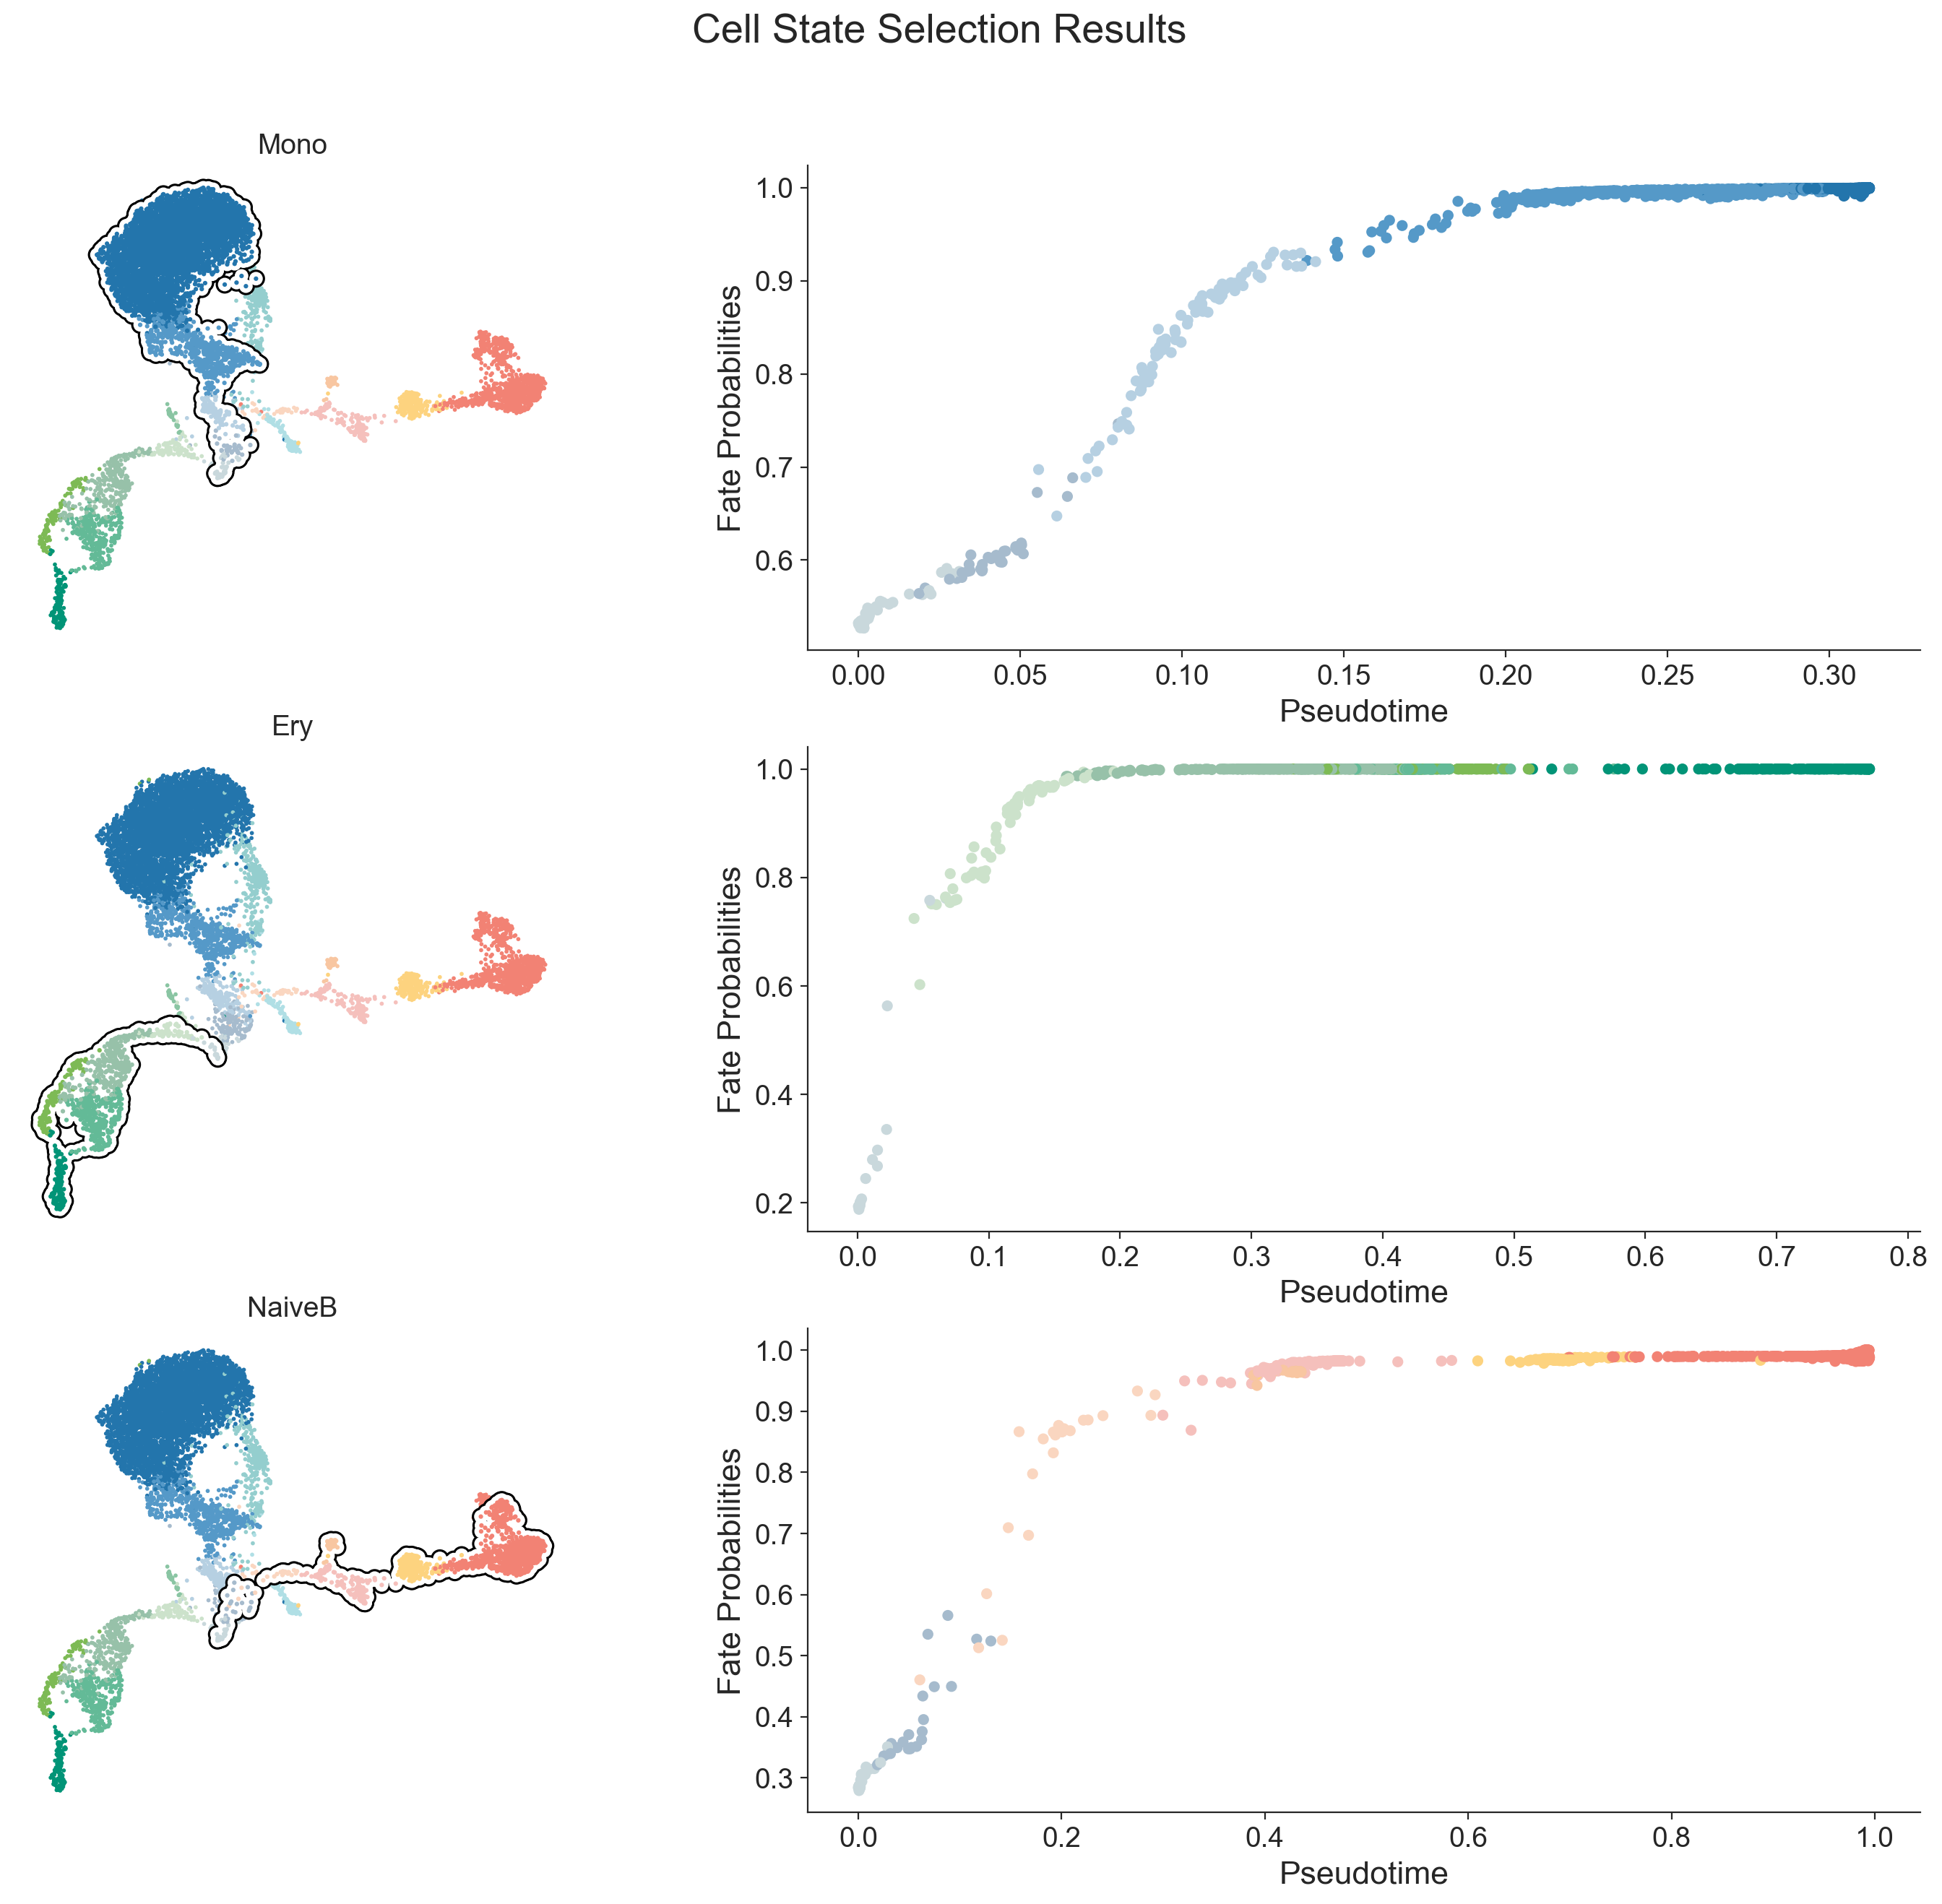

In [80]:
scm.pl.cell_state_select(mdata, mask_key="cell_state_masks", save=os.path.join(fig_dir, "SupFig3-cell_state_select_t_cell.pdf"))

## Test Association

In [41]:
drive_tfs_dict = {
    "NaiveB": ["PAX5", "EBF1", "TCF3", "IKZF1", "SPIB", "POU2F2", "FOXO1", "IRF4", "SOX4", "MEF2C"],
    "Mono":   ["SPI1", "CEBPA", "IRF8", "KLF4", "MAFB", "CEBPB", "IRF5", "NR4A1", "CUX1", "EGR2"],
    "Ery":    ["GATA1", "ZFPM1", "GFI1B", "KLF1", "SPI1", "GATA2", "LDB1", "TAL1", "ZFPM1"],
}

In [42]:
driver_tfs = list(set([tf for tfs in drive_tfs_dict.values() for tf in tfs]) & set(mdata["RNA"][:, mdata["RNA"].var["significant_genes"]].var_names))

DEBUG    DEBUG: Plotting with rc_params: {'font.family': ['sans-serif'], 'font.sans-serif': ['Arial', 'DejaVu      
         Sans', 'Liberation Sans', 'Bitstream Vera Sans', 'sans-serif'], 'font.size': 10, 'axes.labelsize': 12,    
         'axes.titlesize': 14, 'xtick.labelsize': 10, 'ytick.labelsize': 10, 'grid.linewidth': 1,                  
         'lines.linewidth': 1.5, 'figure.facecolor': 'white', 'axes.labelcolor': '.15', 'xtick.direction': 'out',  
         'ytick.direction': 'out', 'xtick.color': '.15', 'ytick.color': '.15', 'axes.axisbelow': True,             
         'grid.linestyle': '-', 'text.color': '.15', 'lines.solid_capstyle': 'round', 'patch.edgecolor': 'w',      
         'patch.force_edgecolor': True, 'image.cmap': 'rocket', 'xtick.top': False, 'ytick.right': False,          
         'axes.grid': False, 'axes.facecolor': 'white', 'axes.edgecolor': '.15', 'grid.color': '.8',               
         'axes.spines.left': True, 'axes.spines.bottom': True, 'axes.spines.right': True, 'axes.spines.top': True, 
         'xtick.bottom': False, 'ytick.left': False}

2025-10-04 16:20:55 | [INFO] maxp pruned
2025-10-04 16:20:55 | [INFO] LTSH dropped
2025-10-04 16:20:55 | [INFO] cmap pruned
2025-10-04 16:20:55 | [INFO] kern dropped
2025-10-04 16:20:55 | [INFO] post pruned
2025-10-04 16:20:55 | [INFO] PCLT dropped
2025-10-04 16:20:55 | [INFO] DSIG dropped
2025-10-04 16:20:55 | [INFO] GPOS pruned
2025-10-04 16:20:55 | [INFO] GSUB pruned
2025-10-04 16:20:55 | [INFO] glyf pruned
2025-10-04 16:20:55 | [INFO] Added gid0 to subset
2025-10-04 16:20:55 | [INFO] Added first four glyphs to subset
2025-10-04 16:20:55 | [INFO] Closing glyph list over 'GSUB': 28 glyphs before
2025-10-04 16:20:55 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'E', 'F', 'G', 'I', 'K', 'L', 'M', 'O', 'P', 'R', 'S', 'T', 'U', 'X', 'Z', 'eight', 'five', 'four', 'nonmarkingreturn', 'one', 'space', 'three', 'two']
2025-10-04 16:20:55 | [INFO] Glyph IDs:   [0, 1, 2, 3, 20, 21, 22, 23, 24, 27, 36, 37, 38, 40, 41, 42, 44, 46, 47, 48, 50, 51, 53, 54, 55, 56, 59, 61]
2025-10-04 16:

INFO     💾 Saving figure to file                                                                                  
         /home/chenxufeng/WorkSpace/scMagnify/scMagnify-figures/figures/Fig3/SupFig3-test_association_t_cell.pdf

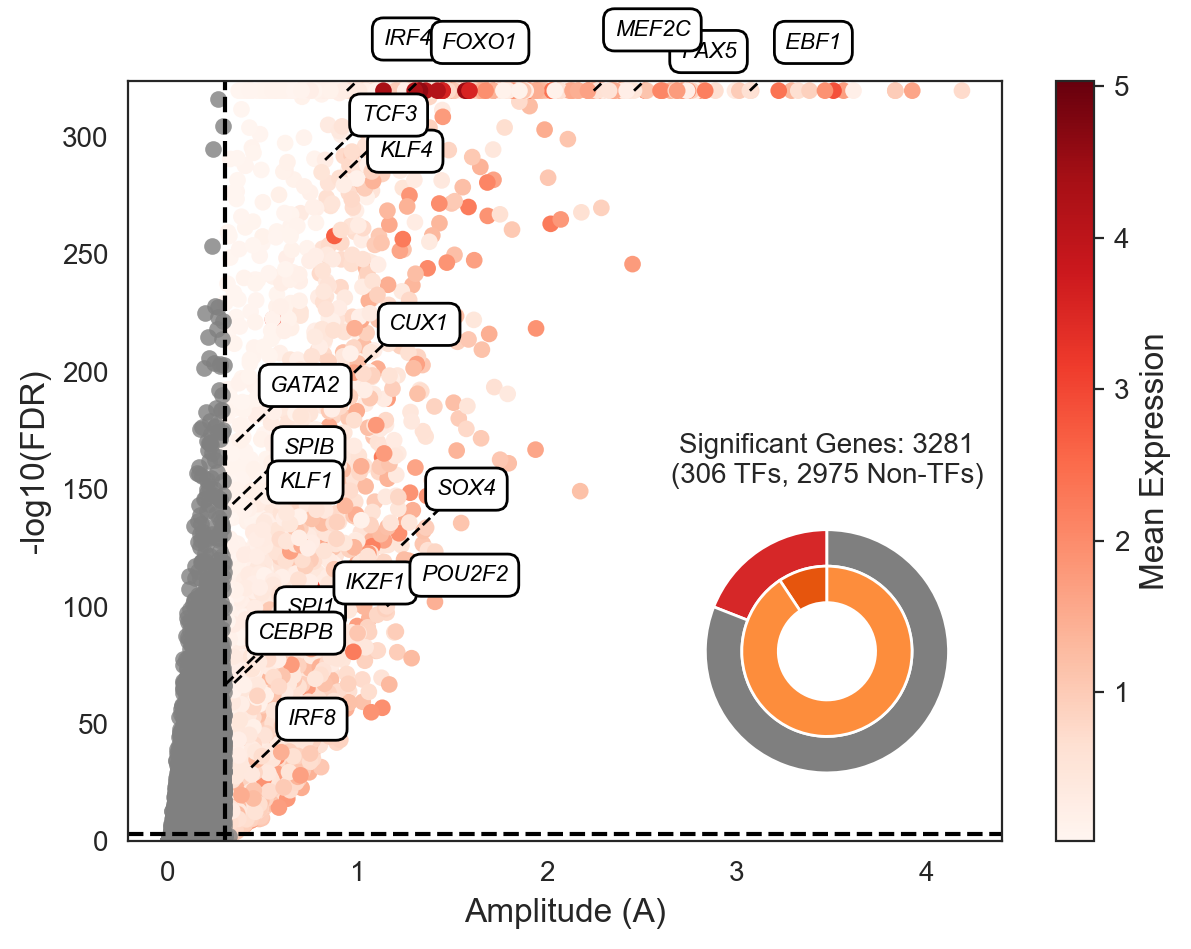

In [44]:
scm.pl.test_association(mdata, selected_genes=driver_tfs, A_cutoff=0.3, save=os.path.join(fig_dir, "SupFig3-test_association_t_cell.pdf"))

## Save the data

In [45]:
cell_state_masks = mdata["RNA"].obsm["cell_state_masks"].copy()
cell_state_masks.to_csv(os.path.join(data_dir, "Fig3-cell_state_masks_t_cell.csv"))

In [46]:
mdata["RNA"]

AnnData object with n_obs × n_vars = 8627 × 17226
    obs: 'sample', 'celltype', 'palantir_pseudotime', 'macrostates_fwd', 'term_states_fwd', 'term_states_fwd_probs', 'clusters_gradients', 'init_states_fwd', 'init_states_fwd_probs', 'n_counts', 'SEACell'
    var: 'highly_variable', 'significant_genes', 'means', 'dispersions', 'dispersions_norm'
    uns: 'T_fwd_params', 'celltype_colors', 'clusters_gradients_colors', 'coarse_fwd', 'eigendecomposition_fwd', 'hvg', 'init_states_fwd_colors', 'log1p', 'macrostates_fwd_colors', 'neighbors', 'sample_colors', 'schur_matrix_fwd', 'term_states_fwd_colors', 'test_assoc', 'umap'
    obsm: 'T_fwd_umap', 'X_FDL', 'X_fate_simplex_fwd', 'X_pca', 'X_umap', 'cell_state_masks', 'cellrank_fate_probabilities', 'init_states_fwd_memberships', 'lineages_fwd', 'macrostates_fwd_memberships', 'schur_vectors_fwd'
    varm: 'test_assoc_res'
    layers: 'MAGIC_imputed_data', 'counts', 'log1p_norm'
    obsp: 'connectivities', 'distances', 'knn'

In [47]:
test_assoc_res = mdata["RNA"].varm["test_assoc_res"].copy()
test_assoc_res.to_csv(os.path.join(data_dir, "Fig3-test_assoc_res_t_cell.csv"))